# Layout Detection Test

Run the YOLOv8 layout model on sample handwritten pages and visualize detected boxes. (Pranav)

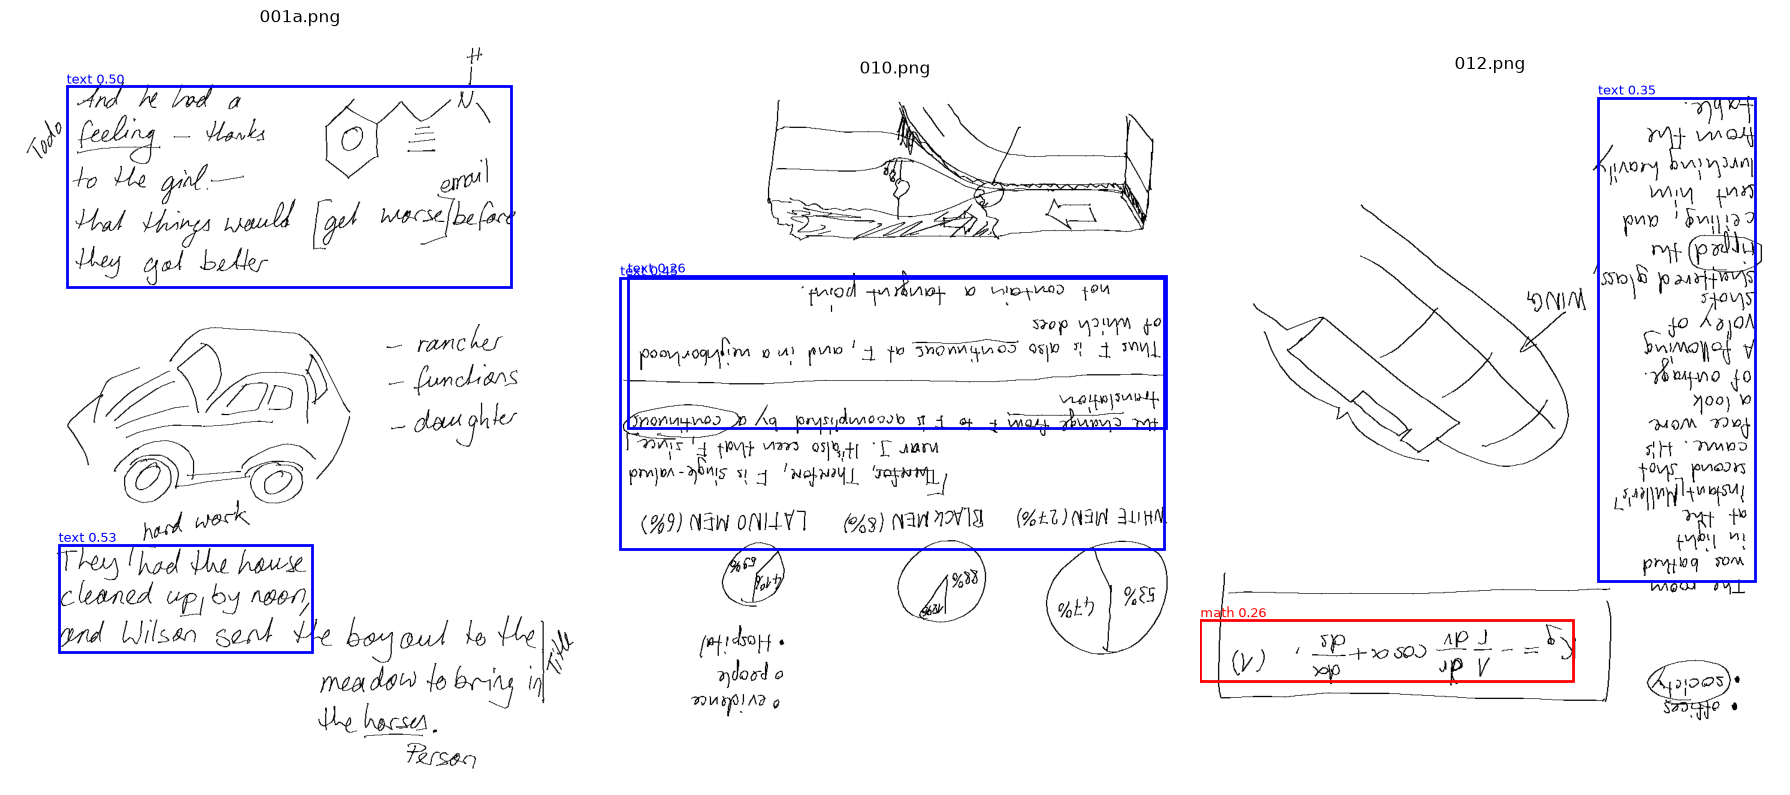

In [1]:
import sys
sys.path.insert(0, "../backend")

from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
from PIL import Image

from app.services.layout_detector import LayoutDetector

detector = LayoutDetector("../weights/yolov8_layout.pt", device="cpu")

DATA_DIR = Path("../backend/data/layout_processed/val/images")
sample_paths = sorted(DATA_DIR.glob("*.png"))[:3]

colors = {"text": "blue", "math": "red"}
fig, axes = plt.subplots(1, len(sample_paths), figsize=(6 * len(sample_paths), 8))

for ax, path in zip(axes, sample_paths):
    image = Image.open(path)
    blocks = detector.detect(image)

    ax.imshow(image, cmap="gray")
    for block in blocks:
        b = block.bbox
        rect = patches.Rectangle(
            (b.x1, b.y1),
            b.x2 - b.x1,
            b.y2 - b.y1,
            linewidth=2,
            edgecolor=colors[block.type],
            facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(b.x1, b.y1 - 5, f"{block.type} {block.confidence:.2f}", color=colors[block.type], fontsize=9)
    ax.set_title(path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()